#  Student Productivity Prediction — Random Forest Regressor

**Dataset:** `ultimate_student_productivity_dataset_5000.csv`  
**Task:** Regression — Prediksi **Productivity Score**  
**Model:** Random Forest Regressor

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../ultimate_student_productivity_dataset_5000.csv')
print(f'Shape: {df.shape}')
df.info()
print('\n', df.describe().round(2))

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

---
## 2.  Dataset Bisa Digunakan Untuk Apa

**Kolom penting:**
- **Waktu belajar:** `study_hours`, `self_study_hours`, `online_classes_hours`
- **Kesehatan:** `sleep_hours`, `exercise_minutes`, `mental_health_score`
- **Distraksi:** `social_media_hours`, `gaming_hours`, `screen_time_hours`
- **Kondisi:** `caffeine_intake_mg`, `part_time_job`, `internet_quality`
- **Target:** `productivity_score`, `exam_score`

In [3]:
target = 'productivity_score'
drop_cols = ['student_id', 'exam_score']

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target])
y = df_proc[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (4000, 18), Test: (1000, 18)


---
## 3.  Kenapa Random Forest Regressor?

| Keunggulan | Detail |
|------------|--------|
| Tidak perlu scaling | Tree-based: tidak terpengaruh skala fitur |
| Feature importance | Langsung tersedia |
| Non-linear | Menangkap interaksi kompleks antar fitur |
| Robust terhadap outlier | Karena median-based splitting |
| OOB Score | Out-of-bag estimate mendekati CV tanpa ekstra waktu |

**Cocok untuk produktivitas:** Hubungan antara jam tidur, belajar, mental health kemungkinan **non-linear** — contoh: tidur 5 jam sama buruknya dengan tidur 10 jam (U-shape).

In [4]:
model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt',
    oob_score=True, n_jobs=-1, random_state=42
)
model.fit(X_train, y_train)
print(f'Training selesai ')
print(f'OOB R²: {model.oob_score_:.4f}')

Training selesai 
OOB R²: 0.8739


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `n_estimators` | 100 | Lebih banyak pohon → lebih stabil |
| `max_depth` | None | Batasi untuk mencegah overfitting |
| `min_samples_split` | 2 | Min sample untuk split |
| `min_samples_leaf` | 1 | Min sample di leaf |
| `max_features` | `'sqrt'` | Jumlah fitur per split |
| `oob_score` | False | Aktifkan untuk estimasi validasi gratis |
| `max_samples` | None | Subsampling data (seperti bootstrap) |

---
## 5.  Evaluasi Yang Dipakai

In [5]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print('='*55)
print(' EVALUASI RANDOM FOREST REGRESSOR (PRODUCTIVITY)')
print('='*55)
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')
print(f'OOB R²: {model.oob_score_:.4f}')

cv = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'CV R²: {cv.mean():.4f} ± {cv.std():.4f}')

 EVALUASI RANDOM FOREST REGRESSOR (PRODUCTIVITY)
MAE  : 4.9617
RMSE : 6.1563
R²   : 0.8545
MAPE : 31.69%
OOB R²: 0.8739
CV R²: 0.8709 ± 0.0075


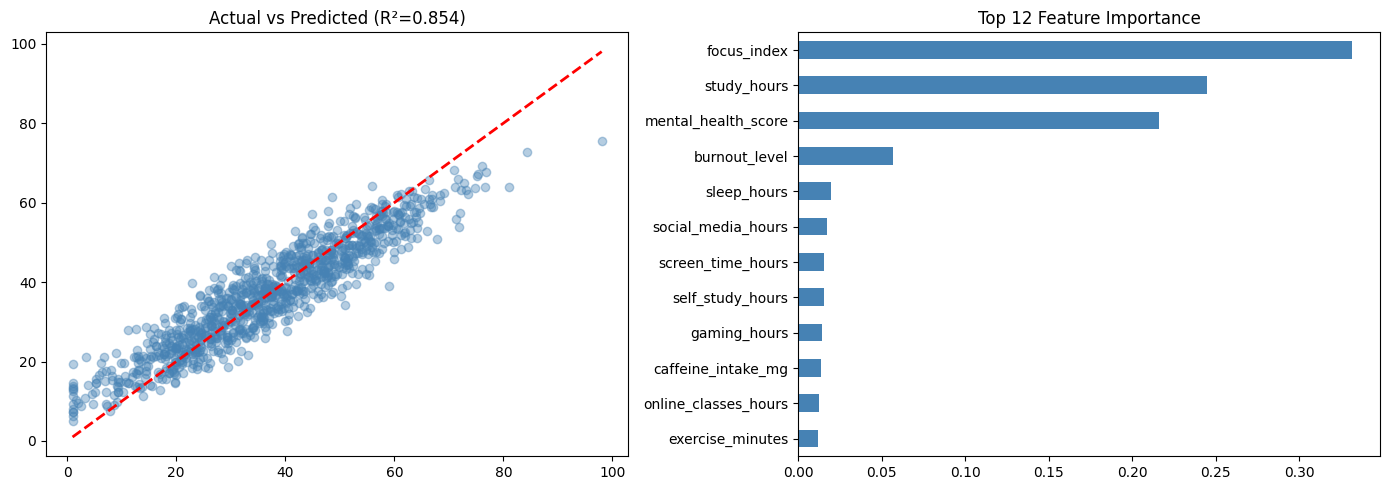

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 12 Feature Importance')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

In [7]:
r2_train = r2_score(y_train, model.predict(X_train))
print(f'Train R²  : {r2_train:.4f}')
print(f'Test R²   : {r2:.4f}')
print(f'OOB R²    : {model.oob_score_:.4f}')
print(f'Overfit gap: {r2_train - r2:.4f}')
if r2_train - r2 > 0.1:
    print(' Overfitting! Kurangi max_depth atau tambah min_samples_leaf')
else:
    print(' Model generalisasi dengan baik')

Train R²  : 0.9671
Test R²   : 0.8545
OOB R²    : 0.8739
Overfit gap: 0.1126
 Overfitting! Kurangi max_depth atau tambah min_samples_leaf


---
## 7.  Cara Mengoptimasi Model

In [8]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.5, 'sqrt', 0.8]
}
rs = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_dist, n_iter=12, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
best = rs.best_estimator_
yp_best = best.predict(X_test)
print(f'Best params: {rs.best_params_}')
print(f'Best R²: {r2_score(y_test, yp_best):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, yp_best)):.4f}')

Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
Best R²: 0.8796, RMSE: 5.5985


---
## 8.  Cara Menyimpan Model

In [9]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best, 'saved_models/rf_reg_productivity.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_cols_rf_prod_reg.pkl')
print(' RF Regressor tersimpan!')

 RF Regressor tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [10]:
loaded_model = joblib.load('saved_models/rf_reg_productivity.pkl')
loaded_cols = joblib.load('saved_models/feature_cols_rf_prod_reg.pkl')
print('Model dimuat ')

new_students = pd.DataFrame([
    {'age': 21, 'gender': 1, 'academic_level': 1, 'study_hours': 5.5, 'self_study_hours': 2,
     'online_classes_hours': 2, 'social_media_hours': 2, 'gaming_hours': 1, 'sleep_hours': 7.5,
     'screen_time_hours': 5, 'exercise_minutes': 30, 'caffeine_intake_mg': 150,
     'part_time_job': 0, 'upcoming_deadline': 1, 'internet_quality': 2,
     'mental_health_score': 7.5, 'focus_index': 7, 'burnout_level': 3},
    {'age': 23, 'gender': 0, 'academic_level': 2, 'study_hours': 2, 'self_study_hours': 1,
     'online_classes_hours': 1, 'social_media_hours': 4, 'gaming_hours': 3, 'sleep_hours': 6,
     'screen_time_hours': 8, 'exercise_minutes': 10, 'caffeine_intake_mg': 250,
     'part_time_job': 1, 'upcoming_deadline': 0, 'internet_quality': 1,
     'mental_health_score': 5, 'focus_index': 4, 'burnout_level': 6}
])[loaded_cols]

preds = loaded_model.predict(new_students)
print('\nHasil Prediksi:')
for i, p in enumerate(preds):
    level = 'Tinggi ' if p >= 75 else ('Sedang ' if p >= 50 else 'Rendah ')
    print(f'  Mahasiswa {i+1}: Productivity Score = {p:.1f} → {level}')

Model dimuat 

Hasil Prediksi:
  Mahasiswa 1: Productivity Score = 39.0 → Rendah 
  Mahasiswa 2: Productivity Score = 16.5 → Rendah 
